## 1.Import Necessary libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

## 2.Import Dataset

In [3]:
cars_data = pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3.Data Understanding

### 3.1 Perform Initial Investigation on the data

In [4]:
cars_data.shape

(81, 5)

In [5]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Now, let's check for the assumption

## Task 1:Linearity Test

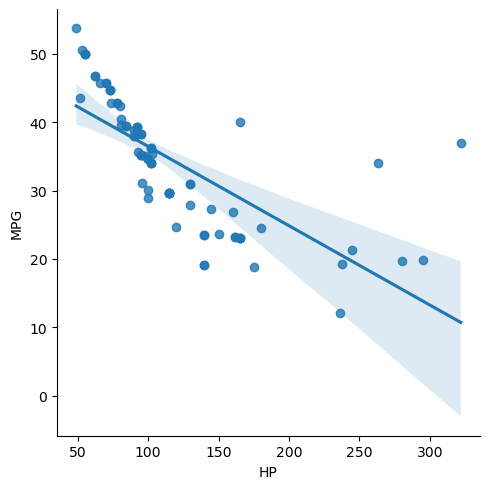

In [8]:
sns.lmplot(data = cars_data, x= "HP",y = "MPG")

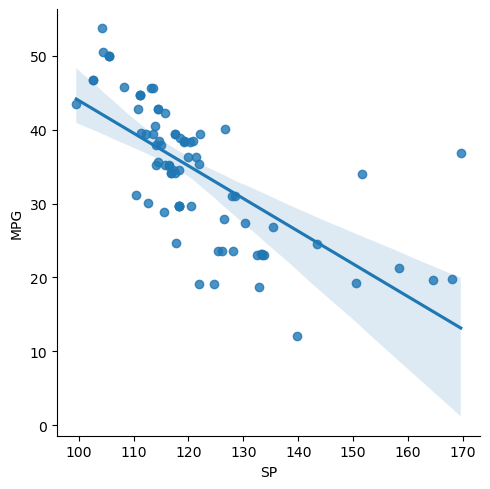

In [9]:
sns.lmplot(data = cars_data, x= "SP",y = "MPG")

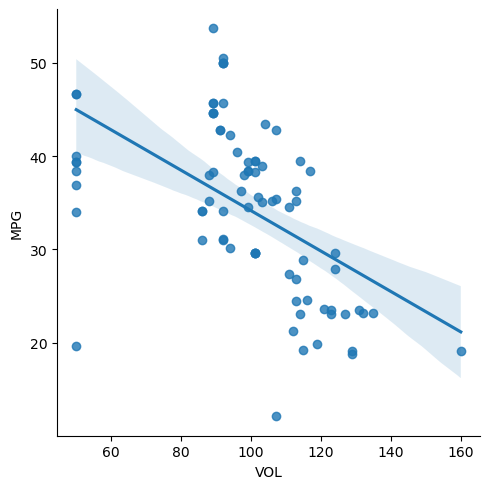

In [10]:
sns.lmplot(data = cars_data, x= "VOL",y = "MPG")

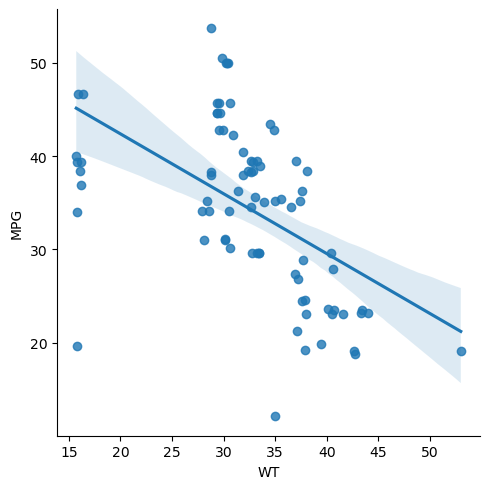

In [11]:
sns.lmplot(data = cars_data, x= "WT",y = "MPG")

###  Test 1 Linearity fail

## Test 2 :Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

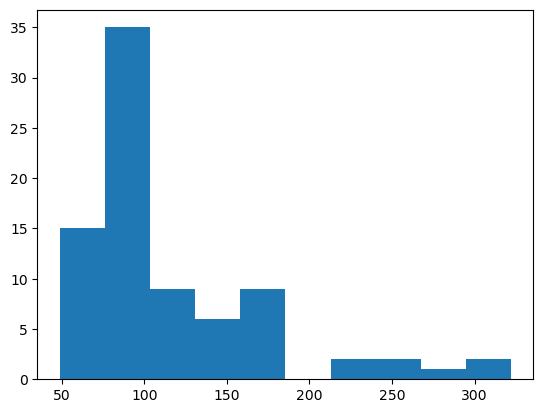

In [12]:
plt.hist(data = cars_data,x = "HP")

<Axes: xlabel='HP', ylabel='Density'>

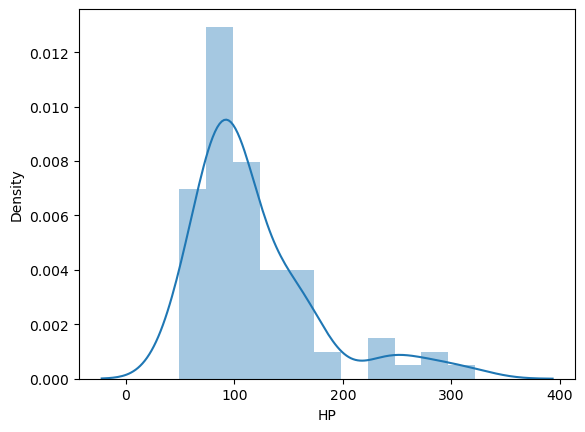

In [13]:
sns.distplot(cars_data["HP"])

<Axes: xlabel='SP', ylabel='Density'>

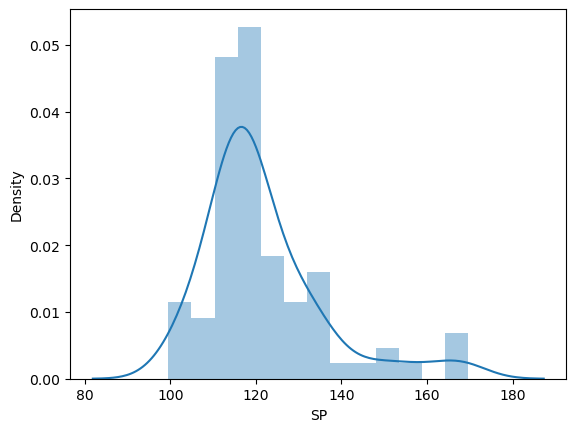

In [14]:
sns.distplot(cars_data["SP"])

<Axes: xlabel='WT', ylabel='Density'>

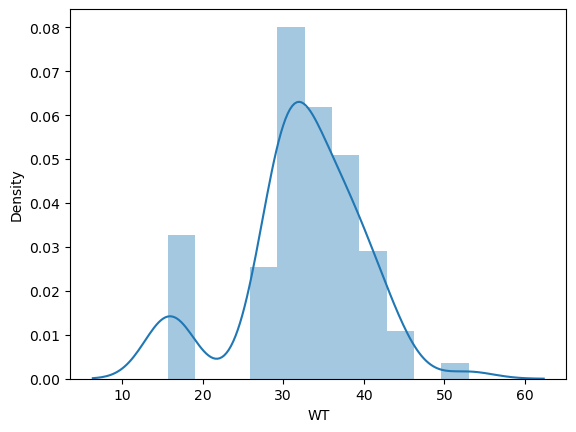

In [15]:
sns.distplot(cars_data["WT"])

<Axes: xlabel='VOL', ylabel='Density'>

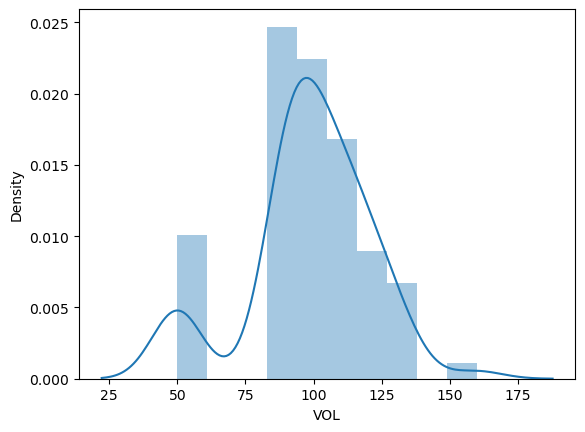

In [16]:
sns.distplot(cars_data["VOL"])

### Test 2 Normality test also failed

In [17]:
corr_matris = cars_data.corr()
corr_matris

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

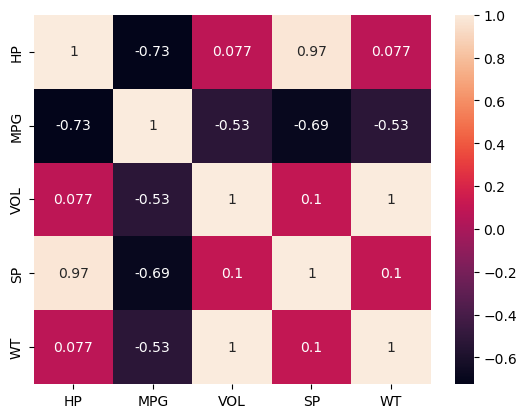

In [18]:
sns.heatmap(corr_matris,annot=True)

### Test 3 There is Multicollinearity in the Data

### Test 3 - AutoRegression Passed

## 4.Data Prepuration

In [19]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [20]:
x = cars_data[["HP","VOL","SP","WT"]]
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [21]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

### There is nothing to prepare becasue all features are numeric.

## 5.Model Building

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=20,random_state=42)

In [28]:
x_train

,HP,VOL,SP,WT
9,80,94,115.645204,30.920154
64,150,121,128.128401,40.159482
5,70,89,113.185353,29.591768
47,98,103,116.472936,33.910056
34,81,101,111.288996,32.701644
...,...,...,...,...
20,92,99,119.105055,32.324650
60,145,111,130.208698,36.888153
71,162,135,133.415985,44.013139
14,66,89,108.185353,29.347279


In [26]:
linear_model = LinearRegression()

## 6.Model Training

In [29]:
linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7.Model Testing

In [30]:
linear_model.intercept_

np.float64(19.01073591014605)

In [31]:
linear_model.coef_

array([-0.21634953, -0.46811179,  0.5168318 ,  0.73597306])

In [32]:
y_train_predit = linear_model.predict(x_train)
y_train_predit

array([40.22578538, 25.69390971, 42.480854  , 34.74677338, 35.79235488,
       24.47942502, 37.05188   , 28.89163001, 40.38452907, 36.37602738,
       34.45257039, 15.85970692, 46.88117306, 32.43133993, 28.96888288,
       37.22193557, 26.37280398, 46.73649043, 34.6035301 , 40.6411352 ,
       19.41984756, 41.98478438, 48.39807848, 38.17926649, 47.2577892 ,
       36.90185269, 40.85718671, 38.47469904, 22.8891114 , 34.12392274,
       33.37138848, 15.29569978, 40.80753155, 38.48651927, 34.43942414,
       34.76358992, 37.3945539 , 39.57693872, 37.09118467, 28.66217309,
       32.07848812, 48.07381842, 36.61015127, 25.4679187 , 30.9954398 ,
       25.88036219, 22.72671664, 37.6268547 , 35.77335369, 40.97373055,
       28.04541608, 35.89047205, 40.77263592, 38.80947886, 20.91518939,
       22.68487044, 38.11086413, 30.12432925, 22.1131292 , 40.58215556,
       32.59528324])

In [34]:
y_test_predict = linear_model.predict(x_test)
y_test_predict

array([33.38725859, 41.76206405, 37.39594762, 36.05220376, 40.67421548,
       35.91395637, 40.63002577, 31.74237128, 40.46443769, 40.02120819,
       32.61129827, 34.4389574 , 23.55038267, 36.59254402, 24.42170468,
       35.56518423, 17.2856368 , 27.42691674, 28.04166484, 33.23620674])

## 8.Model Evaluation

In [32]:
error = y - y_predit
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [47]:
error_Train = y_train-y_train_predit
error_Train

9     2.073293
64   -2.088751
5     3.215468
47    0.305556
34    3.739278
        ...   
20    0.300139
60   -2.770064
71    1.090440
14    5.152737
51   -2.965347
Name: MPG, Length: 61, dtype: float64

In [49]:
error_test = y_test-y_test_predict
error_test

30     6.043977
0     11.938617
22     0.914658
31     3.379031
18     2.115693
28     7.555478
10     4.022808
70   -12.063865
4     10.039794
12    -0.667114
49    -2.981362
33     1.846499
67    -0.447211
35     1.366199
68    -1.318533
45    -1.003685
73     1.800704
61    -2.817785
55    -0.185413
40     1.916520
Name: MPG, dtype: float64

In [58]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

#### Train Data Evaluation

In [41]:
mean_absolute_error(y_train,y_train_predit) #same unit # Predicted result can change chance for a 3.26

3.2956246582136552

In [52]:
mean_squared_error(y_train,y_train_predit)#square unit

18.083879081580314

In [55]:
root_mean_squared_error(y_train,y_train_predit) #normalizing unit

4.2525144422541725

In [59]:
r2_score(y_train,y_train_predit)

0.7703360173911052

#### Test Data Evaluation

In [51]:
mean_absolute_error(y_test,y_test_predict) #same unit # Predicted result can change chance for a 3.72

3.7212473902901886

In [50]:
mean_squared_error(y_test,y_test_predict) #square unit

27.391939049219822

In [57]:
root_mean_squared_error(y_test,y_test_predict) #normalizing unit

5.233730891937397

In [101]:
r2_score(y_test,y_test_predict)

0.7045172216708746

In [102]:
import statsmodels.formula.api as smf

### See Adjested R2 Score,we are using OLS(Ordinary Least Squares) tecniques from StatModel Formula

In [103]:
linear_stats_model = smf.ols(formula ="MPG~HP+VOL+SP+WT" ,data=cars_data).fit()
linear_stats_model

In [105]:
print("R2 score",linear_stats_model.rsquared.round(4),"\nAdj r2 score",linear_stats_model.rsquared_adj.round(4))

R2 score 0.7705 
Adj r2 score 0.7585


In [100]:
linear_stats_model = smf.ols(formula ="MPG~HP" ,data=cars_data).fit()

In [82]:
print("R2 score",linear_stats_model.rsquared.round(4),"\nAdj r2 score",linear_stats_model.rsquared_adj.round(4))

R2 score 0.5257 
Adj r2 score 0.5197


In [99]:
linear_stats_model = smf.ols(formula ="MPG~HP+VOL" ,data=cars_data).fit()

In [92]:
print("R2 score",linear_stats_model.rsquared.round(4),"\nAdj r2 score",linear_stats_model.rsquared_adj.round(4))

R2 score 0.7507 
Adj r2 score 0.7443


In [98]:
linear_stats_model = smf.ols(formula ="MPG~HP+VOL+SP" ,data=cars_data).fit()

In [94]:
print("R2 score",linear_stats_model.rsquared.round(4),"\nAdj r2 score",linear_stats_model.rsquared_adj.round(4))

R2 score 0.7704 
Adj r2 score 0.7614


In [97]:
linear_stats_model = smf.ols(formula ="MPG~HP+VOL+SP+WT" ,data=cars_data).fit()

In [96]:
print("R2 score",linear_stats_model.rsquared.round(4),"\nAdj r2 score",linear_stats_model.rsquared_adj.round(4))

R2 score 0.7705 
Adj r2 score 0.7585


### Let's perform Test 5: Homoscedasticity test

<Axes: xlabel='HP', ylabel='MPG'>

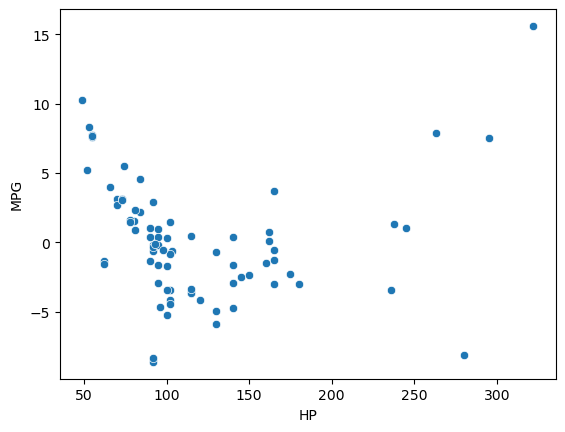

In [27]:
sns.scatterplot(data =cars_data,x="HP",y =error)

<Axes: xlabel='SP', ylabel='MPG'>

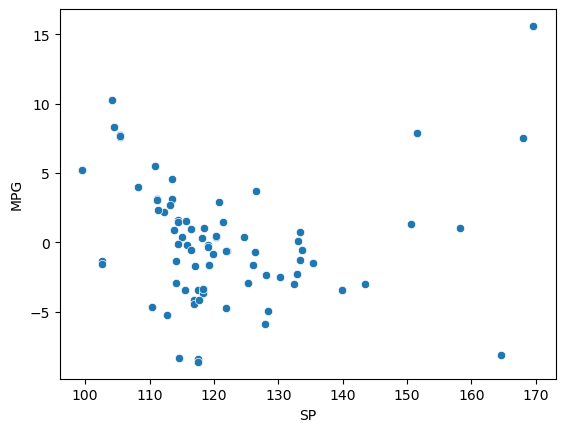

In [28]:
sns.scatterplot(data =cars_data,x="SP",y =error)

<Axes: xlabel='VOL', ylabel='MPG'>

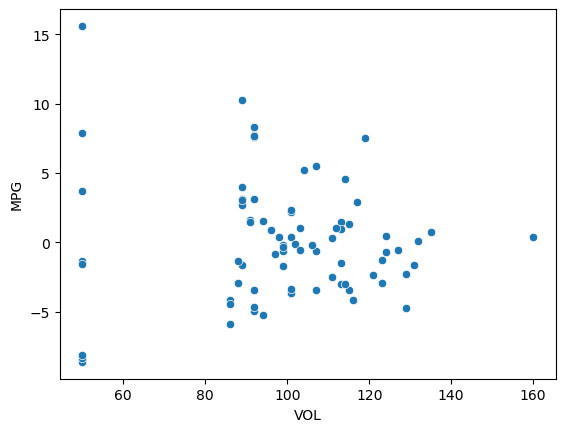

In [29]:
sns.scatterplot(data =cars_data,x="VOL",y =error)

<Axes: xlabel='WT', ylabel='MPG'>

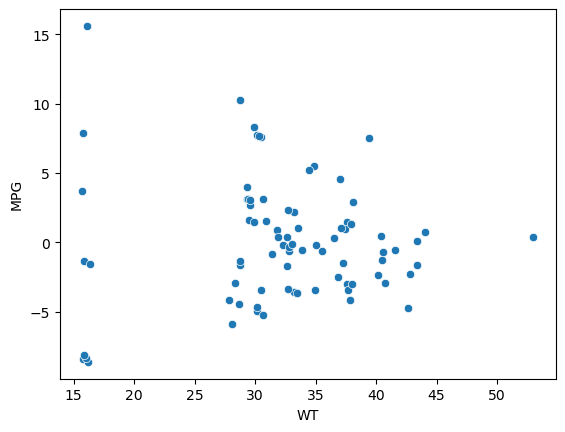

In [30]:
sns.scatterplot(data =cars_data,x="WT",y =error)

### Test 5 Homoscedasticity test also failed

### Test 6: Zero Residual Mean Test 

<Axes: xlabel='MPG'>

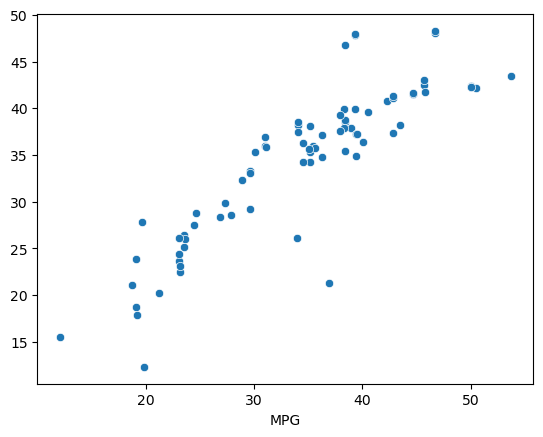

In [31]:
sns.scatterplot(x = cars_data["MPG"],y = y_predit)

### Test 6 : Zero Residual Mean Test is also failed 

## 9.Model Deployment

In [55]:
from pickle import dump

In [56]:
dump(obj = linear_model,file = open(file="linear_Intelligence_file.pkl",mode="wb"))

In [57]:
from pickle import load

In [59]:
linear_intal_pkl = load(file = open(file="linear_Intelligence_file.pkl",mode="rb"))
linear_intal_pkl

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
    linear_intal_pkl.predict(x)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

# THE END !!!!